Prediksi Kelulusan Mahasiswa Menggunakan Machine Learning

Cell 2 (Code) - Import Library

In [1]:
# Import Library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

pd.set_option('display.max_columns', None)

Cell 3 (Code) - Upload dan Load Dataset

In [6]:
# Upload dan Load Dataset

from google.colab import files
uploaded = files.upload()
df = pd.read_csv(
    "Predict Student Dropout and Academic Success (3).csv",
    sep=";"
)
print("Dataset berhasil dimuat.")

Saving Predict Student Dropout and Academic Success.csv to Predict Student Dropout and Academic Success (4).csv
Dataset berhasil dimuat.


Cell 4 (Code) - Menampilkan Data

In [13]:
# Menampilkan Data

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Not Graduate
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Not Graduate
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Cell 5 (Code) - Data Understanding

In [7]:
# Data Understanding

print("Ukuran Dataset:")
print(df.shape)

print("\nInformasi Dataset:")
df.info()

print("\nStatistik Deskriptif:")
display(df.describe())

print("\nMissing Value:")
display(df.isnull().sum())

print("\nJumlah Data Duplikat:")
print(df.duplicated().sum())

print("\nDistribusi Target:")
display(df["Target"].value_counts())

Ukuran Dataset:
(4424, 37)

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,10.960895,11.032324,126.978119,0.548373,0.011528,0.113698,0.880651,0.351718,0.248418,23.265145,0.024864,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,26.418253,25.263040,14.482001,0.497711,0.106760,0.317480,0.324235,0.477560,0.432144,7.587816,0.155729,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,0.000000,0.000000,95.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,4.000000,4.000000,117.900000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,19.000000,0.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,5.000000,7.000000,126.100000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,20.000000,0.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,9.000000,9.000000,134.800000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,25.000000,0.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,194.000000,195.000000,190.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,1.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000



Missing Value:


,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance\t,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0



Jumlah Data Duplikat:
0

Distribusi Target:


,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


Cell 6 (Code) - Data Preparation

In [8]:
# Data Preparation

# Mengubah target menjadi 2 kelas
df["Target"] = df["Target"].replace({
    "Dropout": "Not Graduate",
    "Enrolled": "Not Graduate"
})

print("Distribusi Target Setelah Perubahan:")
display(df["Target"].value_counts())

Distribusi Target Setelah Perubahan:


,count
Target,
Not Graduate,2215
Graduate,2209


Cell 7 (Code) - Visualisasi Target

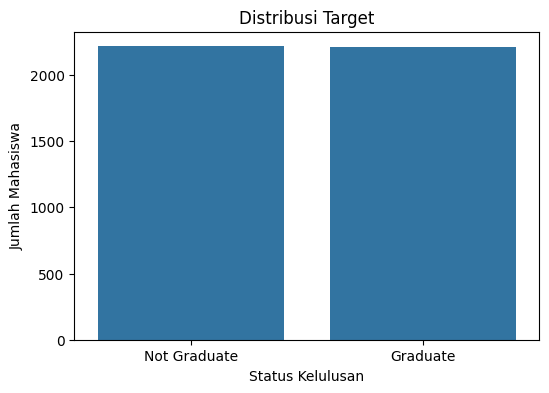

In [9]:
# Visualisasi Target

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Target")

plt.title("Distribusi Target")
plt.xlabel("Status Kelulusan")
plt.ylabel("Jumlah Mahasiswa")

plt.show()

Cell 8 (Code) - Distribusi Usia Mahasiswa

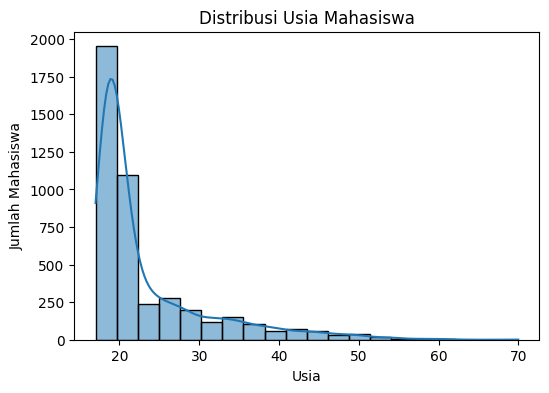

In [14]:
# Distribusi Usia Mahasiswa

plt.figure(figsize=(6,4))

sns.histplot(df["Age at enrollment"], bins=20, kde=True)

plt.title("Distribusi Usia Mahasiswa")
plt.xlabel("Usia")
plt.ylabel("Jumlah Mahasiswa")

plt.show()

Cell 9 (Code) - Status Beasiswa terhadap Kelulusan

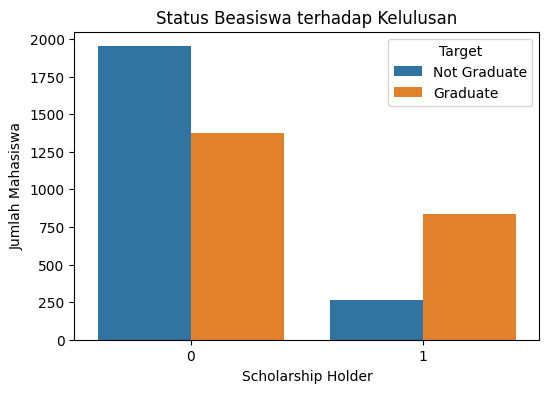

In [15]:
# Status Beasiswa terhadap Kelulusan

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Scholarship holder", hue="Target")

plt.title("Status Beasiswa terhadap Kelulusan")
plt.xlabel("Scholarship Holder")
plt.ylabel("Jumlah Mahasiswa")

plt.show()

Cell 10 (Code) - Status Pembayaran UKT terhadap Kelulusan

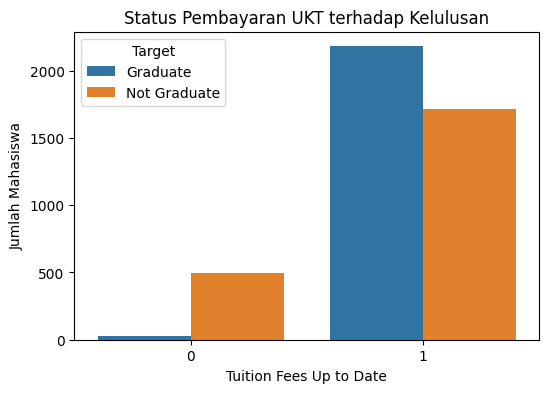

In [16]:
# Status Pembayaran UKT terhadap Kelulusan

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Tuition fees up to date", hue="Target")

plt.title("Status Pembayaran UKT terhadap Kelulusan")
plt.xlabel("Tuition Fees Up to Date")
plt.ylabel("Jumlah Mahasiswa")

plt.show()

Cell 11 - Heatmap Korelasi

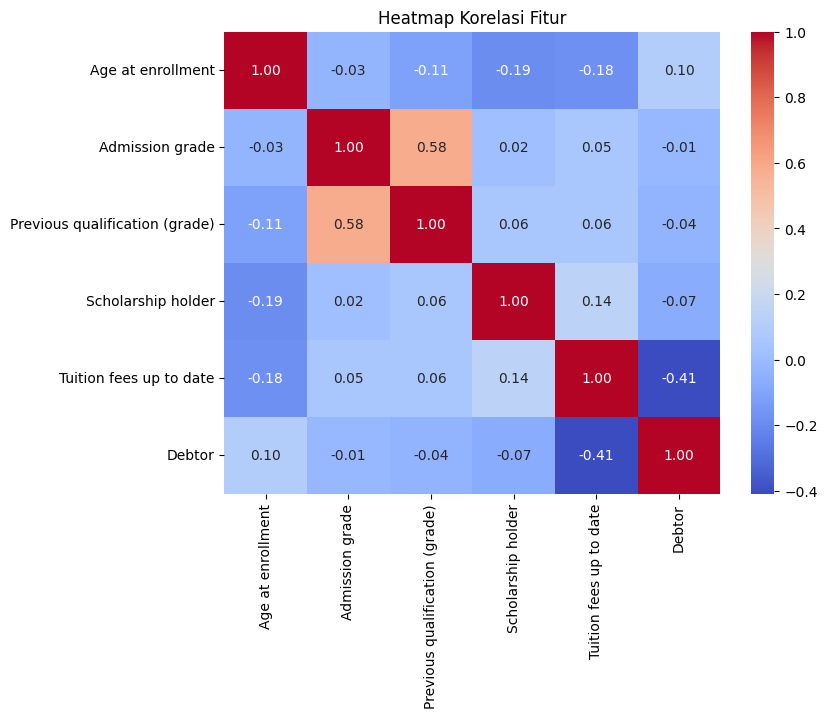

In [18]:
# Heatmap Korelasi

selected_features = [
    "Age at enrollment",
    "Admission grade",
    "Previous qualification (grade)",
    "Scholarship holder",
    "Tuition fees up to date",
    "Debtor"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[selected_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Heatmap Korelasi Fitur")

plt.show()

Cell 12 (Code) - Memisahkan Fitur dan Target

In [19]:
# Memisahkan Fitur dan Target

X = df.drop("Target", axis=1)
y = df["Target"]

print("Jumlah fitur:", X.shape[1])
print("Jumlah data:", X.shape[0])

Jumlah fitur: 36
Jumlah data: 4424


Cell 13 (Code) - Encoding Target

In [20]:
# Encoding Target

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print("Label Target:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label} = {i}")

Label Target:
Graduate = 0
Not Graduate = 1


Cell 14 (Code) - Membagi Data Training dan Testing

In [21]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Training :", X_train.shape)
print("Data Testing  :", X_test.shape)

Data Training : (3539, 36)
Data Testing  : (885, 36)


Cell 15 (Code) - Melatih Model Decision Tree

In [22]:
# Model Decision Tree

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

Cell 16 (Code) - Evaluasi Decision Tree

In [23]:
# Evaluasi Decision Tree

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1-Score :", f1_score(y_test, y_pred_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.7548022598870057
Precision: 0.7603686635944701
Recall   : 0.744920993227991
F1-Score : 0.7525655644241733

Classification Report
              precision    recall  f1-score   support

           0       0.75      0.76      0.76       442
           1       0.76      0.74      0.75       443

    accuracy                           0.75       885
   macro avg       0.75      0.75      0.75       885
weighted avg       0.75      0.75      0.75       885



Cell 17 (Code) - Confusion Matrix Decision Tree

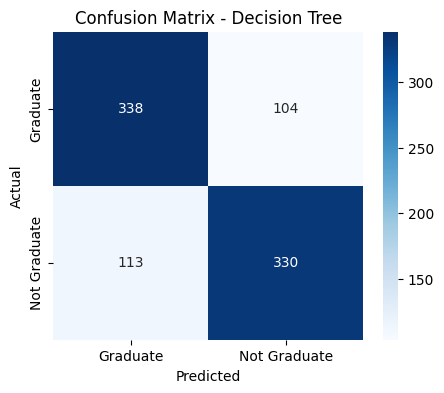

In [24]:
# Confusion Matrix Decision Tree

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

Cell 18 (Code) - Model Random Forest

In [25]:
# Model Random Forest

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

Cell 19 (Code) - Evaluasi Random Forest

In [26]:
# Evaluasi Random Forest

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-Score :", f1_score(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.8384180790960452
Precision: 0.8640776699029126
Recall   : 0.8036117381489842
F1-Score : 0.8327485380116959

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       442
           1       0.86      0.80      0.83       443

    accuracy                           0.84       885
   macro avg       0.84      0.84      0.84       885
weighted avg       0.84      0.84      0.84       885



Cell 20 (Code) - Confusion Matrix Random Forest

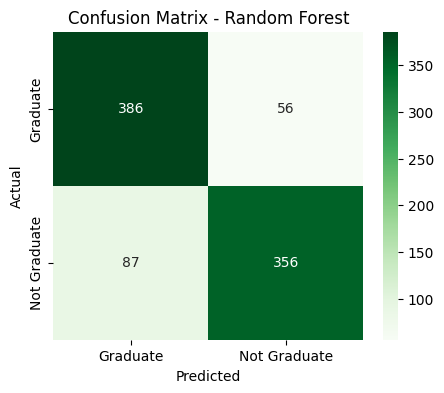

In [27]:
# Confusion Matrix Random Forest

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

Cell 21 (Code) - Perbandingan Model

In [28]:
# Perbandingan Model

comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.754802,0.760369,0.744921,0.752566
1,Random Forest,0.838418,0.864078,0.803612,0.832749


Cell 22 (Code) - Model Terbaik

In [29]:
# Model Terbaik

best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print("Model Terbaik")
print(best_model)

Model Terbaik
Model        Random Forest
Accuracy          0.838418
Precision         0.864078
Recall            0.803612
F1-Score          0.832749
Name: 1, dtype: object


Cell 23 - Feature Importance

In [30]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
30,Curricular units 2nd sem (approved),0.168339
24,Curricular units 1st sem (approved),0.125824
31,Curricular units 2nd sem (grade),0.117492
25,Curricular units 1st sem (grade),0.062205
29,Curricular units 2nd sem (evaluations),0.038535
12,Admission grade,0.037222
23,Curricular units 1st sem (evaluations),0.033939
6,Previous qualification (grade),0.033361
3,Course,0.031599
16,Tuition fees up to date,0.030153


Cell 24 - Visualisasi Feature Importance

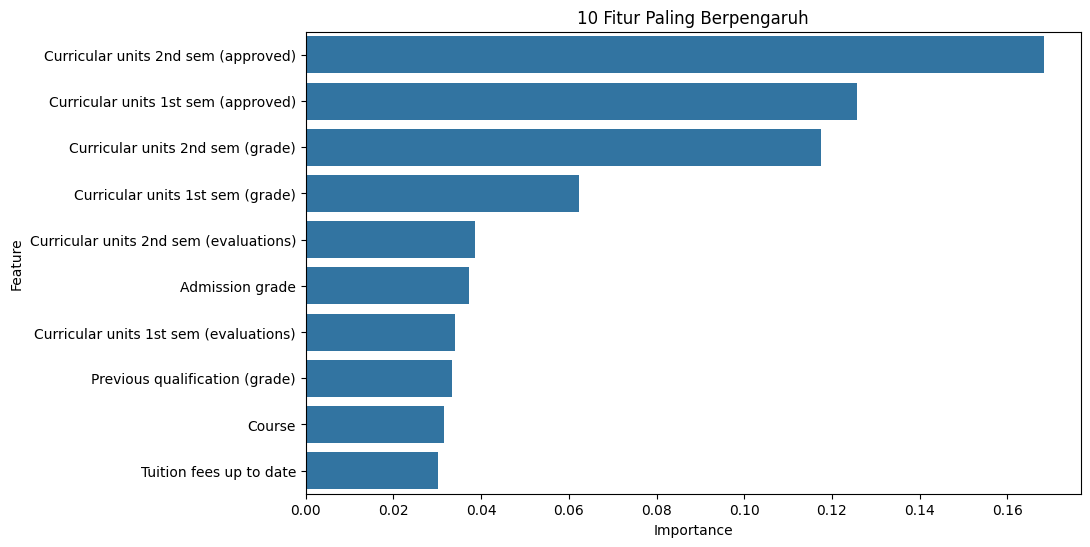

In [31]:
# Visualisasi Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("10 Fitur Paling Berpengaruh")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

Cell 27 - Prediksi Data Baru

In [32]:
# Contoh Prediksi

sample = X_test.iloc[[0]]

prediction = rf_model.predict(sample)

if prediction[0] == 1:
    print("Prediksi : Graduate")
else:
    print("Prediksi : Not Graduate")

Prediksi : Not Graduate
